# Example 05 - Load & Run the Upper Yellowstone PRMS Model

In [1]:
import os
from pathlib import Path
import json
import warnings
import inspect
from typing import Union, Optional

from gsflow import ControlFile, ControlRecord
import numpy as np
import pandas as pd
import xarray as xr
from flopy.discretization import VertexGrid as FlopyVertexGrid

In [ ]:
src_root = (Path('..') / 'src').resolve()
os.chdir(src_root)

from mihms.prep.utils import clip_raster, load_raster_window, check_precip_string, check_min_temp_string, check_max_temp_string, write_prms_datafile
from mihms.config import project_root, prep
from mihms.prep import prms as pprms
from mihms.utils.io import user_warning
from mihms.models.models import PrmsModel

from mihms.output import PrmsOutput

In [3]:
out_pth = Path(os.getcwd()).parent / 'example/Yellowstone'

In [4]:
p = pprms.PRMSParameters.load_paramfile(out_pth / 'UY_calib_params.param')

------------------------------------
Reading parameter file : UY_calib_params.param
------------------------------------


In [11]:
for d in ('nsegment',):
    if d not in p.parameters['x_coef'].dims:
        print('no')
    else:
        print('yes')

yes


In [12]:
p.parameters

<xarray.Dataset> Size: 48MB
Dimensions:               (nlake: 1, nsegment: 1352, nmonths: 12, nhru: 45244,
                           one: 1, nssr: 45244, ngw: 45244)
Dimensions without coordinates: nlake, nsegment, nmonths, nhru, one, nssr, ngw
Data variables: (12/37)
    lake_coef             (nlake) float64 8B 0.1
    K_coef                (nsegment) float64 11kB 24.0 1.0 1.0 ... 1.0 1.0 1.0
    x_coef                (nsegment) float64 11kB 0.5 0.5 0.5 ... 0.5 0.5 0.5
    adjmix_rain           (nmonths, nhru) float64 4MB 1.0 1.0 1.0 ... 1.0 1.0
    tmax_allsnow          (nmonths, nhru) float64 4MB 0.0 0.0 0.0 ... 0.0 0.0
    tmax_allrain_offset   (nmonths, nhru) float64 4MB 0.0 0.0 0.0 ... 0.0 0.0
    ...                    ...
    ppt_rad_adj           (nmonths, nhru) float64 4MB 0.02 0.02 ... 0.02 0.02
    radj_sppt             (nhru) float64 362kB 0.44 0.44 0.44 ... 0.44 0.44 0.44
    radj_wppt             (nhru) float64 362kB 0.5 0.5 0.5 0.5 ... 0.5 0.5 0.5
    radmax                (nmonths, nhru) float64 4MB 0.8 0.8 0.8 ... 0.8 0.8
    tmax_index            (nmonths, nhru) float64 4MB 50.0 50.0 ... 50.0 50.0
    jh_coef               (nmonths, nhru) float64 4MB 0.014 0.014 ... 0.014

In [18]:
p.change_parameter('dday_slope', 0.4, ('nmonths', 'nhru'), idx={'nmonths': 0, 'nhru': 1})
p.parameters['dday_slope']

<xarray.DataArray 'dday_slope' (nmonths: 12, nhru: 45244)> Size: 4MB
array([[0.8, 0.4, 0.8, ..., 0.8, 0.8, 0.8],
       [0.2, 0.2, 0.2, ..., 0.2, 0.2, 0.2],
       [0.3, 0.3, 0.3, ..., 0.3, 0.3, 0.3],
       ...,
       [0.2, 0.2, 0.2, ..., 0.2, 0.2, 0.2],
       [0.1, 0.1, 0.1, ..., 0.1, 0.1, 0.1],
       [0.1, 0.1, 0.1, ..., 0.1, 0.1, 0.1]])
Dimensions without coordinates: nmonths, nhru
Attributes:
    default:    0.4
    desc:       Slope in temperature degree-day relationship
    help:       Monthly (January to December) slope in degree-day equation fo...
    maximum:    1.4
    minimum:    0.1
    modules:    ['ddsolrad']
    type:       F
    units:      dday/temp_units
    dims:       ('nmonth', 'nhru')
    file_name:  C:\Users\CNB968\OneDrive - MT\GitHub\MIHMS\example\Yellowston...

In [9]:
p.parameters['x_coef'].dims

('nsegment',)

In [14]:
c = pprms.CreateControlFile.load_from_prms_controlfile(out_pth / 'UY.control')

['start_time',
 'end_time',
 'executable_model',
 'executable_desc',
 'model_output_file',
 'csv_output_file',
 'param_file',
 'data_file',
 'model_mode']

In [57]:
c.control_obj.get_values('nsegmentOutVar_names')

param_base.py:94: UserWarning: The record does not exist...


In [4]:
prmscont = pprms.CreateControlFile(Path('C:/Users/CNB968/OneDrive - MT/Modeling/GSFLOW/PRMS/prms_6.0.0/bin/prms.exe'), 
                               '6.0.0', 
                               '2020-01-01', 
                               '2024-12-31', 
                               out_pth / 'UYdata.data', 
                               [out_pth / 'UY_static_params.param', out_pth / 'UY_calib_params.param'], 
                               out_pth, 
                               file_name='UY_solrad_et.control')

In [5]:
prmscont.select_output_variables(['basin_swrad', 'swrad', 'basin_actet', 'hru_actet'])

In [17]:
prmscont.control_obj._records_list.append(ControlRecord('aniOutON_OFF', [1], datatype=1))
prmscont.control_obj._records_list.append(ControlRecord('aniOutVar_names', ['swrad', 'hru_actet'], datatype=4))
prmscont.control_obj._records_list.append(ControlRecord('naniOutVars', [2], datatype=1))
prmscont.control_obj._records_list.append(ControlRecord('ani_output_file', [prmscont._out_pth.relative_to(
                                        prmscont.model_wd) / 'ani_test.out'], datatype=4))

In [18]:
prmscont.save_controlfile()

In [6]:
out = PrmsOutput(prmscont)

In [10]:
out.get_hru_output('swrad')

<xarray.Dataset> Size: 662MB
Dimensions:  (time: 1827, hru: 45244)
Coordinates:
  * hru      (hru) <U6 1MB '1' '2' '3' '4' ... '45241' '45242' '45243' '45244'
  * time     (time) datetime64[ns] 15kB 2020-01-01 2020-01-02 ... 2024-12-31
Data variables:
    swrad    (time, hru) float64 661MB 45.78 62.06 42.6 ... 62.87 46.57 51.34

In [16]:
subtest.columns = np.char.strip(subtest.columns.values.astype(str))

In [18]:
subtest['basin_actet']

Date
2020-01-01    0.001416
2020-01-02    0.000660
2020-01-03    0.002112
2020-01-04    0.002665
2020-01-05    0.000486
                ...   
2024-12-27    0.003188
2024-12-28    0.004132
2024-12-29    0.005334
2024-12-30    0.000787
2024-12-31    0.000247
Name: basin_actet, Length: 1827, dtype: float64

In [ ]:
bsntest = pd.read_csv(out_pth / 'UY_')

In [106]:
dstest = xr.Dataset(
    {
        'sub_cfs': (('time', 'subbasin'), subtest.values)
    },
    coords={
        'subbasin': np.char.strip(subtest.columns.values.astype(str)),
        'time': subtest.index.values
    }
)

In [94]:
np.char.strip(subtest.columns.values.astype(str))

array(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19'], dtype='<U3')

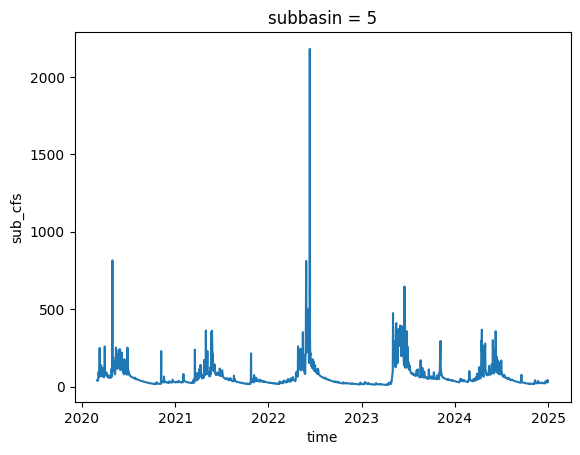

In [110]:
dstest.sub_cfs.sel(subbasin='5', time=slice('2020-03-01', None)).plot()

In [19]:
mod = PrmsModel(prmscont)

------------------------------------
Reading parameter file : UY_static_params.param
------------------------------------
------------------------------------
Reading parameter file : UY_calib_params.param
------------------------------------


prms_parameter.py:217: UserWarning: Duplicate parameter nlake_hrus found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter nrain found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter ndepl found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter nlake found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter nsegment found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter nmonths found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter nhru found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter one found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter nssr found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter ngw found, overwriting with new values
c:\Users\CNB968\.conda\env

In [5]:
mod = PrmsModel(c)

------------------------------------
Reading parameter file : UY_static_params.param
------------------------------------
------------------------------------
Reading parameter file : UY_calib_params.param
------------------------------------


prms_parameter.py:217: UserWarning: Duplicate parameter nlake_hrus found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter nrain found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter ndepl found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter nlake found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter nsegment found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter nmonths found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter nhru found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter one found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter nssr found, overwriting with new values
prms_parameter.py:217: UserWarning: Duplicate parameter ngw found, overwriting with new values


c:\Users\CNB968\.conda\envs\prms\lib\site-packages\gsflow\prms\prms_data.py:91: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_pd = pd.read_csv(fid, delim_whitespace=True, names=columns)


In [7]:
mod.run_model()



                         U.S. Geological Survey
               Precipitation-Runoff Modeling System (PRMS)
                        Version 6.0.0 02/01/2025

--------------------------------------------------------------------
        Process            Available Modules
--------------------------------------------------------------------
  Basin Definition: basin
    Cascading Flow: cascade
  Time Series Data: obs, water_use_read, dynamic_param_read
                    dynamic_soil_param_read
   Potet Solar Rad: soltab
  Temperature Dist: temp_1sta, temp_laps, temp_dist2, climate_hru,
                    temp_map
       Precip Dist: precip_1sta, precip_laps, precip_dist2,
                    climate_hru, precip_map
Temp & Precip Dist: xyz_dist, ide_dist
    Solar Rad Dist: ccsolrad, ddsolrad, climate_hru
Transpiration Dist: transp_tindex, climate_hru, transp_frost
      Potential ET: potet_hamon, potet_jh, potet_pan, climate_hru,
                    potet_hs, potet_pt, potet_pm, pote

(True,
 ['',
  '',
  '                         U.S. Geological Survey',
  '               Precipitation-Runoff Modeling System (PRMS)',
  '                        Version 6.0.0 02/01/2025',
  '',
  '--------------------------------------------------------------------',
  '        Process            Available Modules',
  '--------------------------------------------------------------------',
  '  Basin Definition: basin',
  '    Cascading Flow: cascade',
  '  Time Series Data: obs, water_use_read, dynamic_param_read',
  '                    dynamic_soil_param_read',
  '   Potet Solar Rad: soltab',
  '  Temperature Dist: temp_1sta, temp_laps, temp_dist2, climate_hru,',
  '                    temp_map',
  '       Precip Dist: precip_1sta, precip_laps, precip_dist2,',
  '                    climate_hru, precip_map',
  'Temp & Precip Dist: xyz_dist, ide_dist',
  '    Solar Rad Dist: ccsolrad, ddsolrad, climate_hru',
  'Transpiration Dist: transp_tindex, climate_hru, transp_frost',
  '      

In [21]:
import geopandas as gpd
pourpnts_pth = Path(r'D:\ArcGIS_Projects\Yellowstone\Upper Yellowstone\Vector\prms_subbasin_pourpnts.shp')
pourpnts = gpd.read_file(pourpnts_pth)

data_pth = Path('C:/Users/CNB968/OneDrive - MT/Yellowstone/Upper Yellowstone/UY_all_gage_data.csv')
df = pd.read_csv(data_pth, parse_dates=True)

grid_pth = Path('D:/ArcGIS_Projects/Yellowstone/Upper Yellowstone/prms/UY_prms_grid.shp')
geom_grid = gpd.read_file(grid_pth)

In [28]:
def create_obs_dataset(
    obs_data,
    obs_geom,
    col_link,
    model_grid,
    sub_basins=None,
    stream_array=None
):
    if isinstance(model_grid, (str, Path)):
        fpgrid = pprms.PRMSVertexGrid(model_grid)
        geom_grid = fpgrid.geo_dataframe
    elif isinstance(model_grid, (pprms.PRMSVertexGrid, FlopyVertexGrid)):
        geom_grid = model_grid.geo_dataframe
    elif isinstance(model_grid, gpd.GeoDataFrame):
        geom_grid = model_grid
    else:
        raise ValueError("The input grid object type is not supported.")

    geom_grid['hru'] = geom_grid.index + 1

    # this is to deal with shapefiles...they clip the column headers output by the PRMSCascades class
    #   the column names should be set as 'hru_subbasin' and 'stream_grid'
    sub_name = [c for c in geom_grid.columns if 'hru_sub' in c]
    if len(sub_name) != 0:
        geom_grid.rename(columns={sub_name[0]: 'hru_subbasin'}, inplace=True)
        sub_name = True
    else:
        sub_name = False
    strm_name = [c for c in geom_grid.columns if 'stream_g' in c]
    if len(strm_name) != 0:
        geom_grid.rename(columns={strm_name[0]: 'stream_grid'}, inplace=True)
        strm_name = True
    else:
        strm_name = False

    if (not sub_name) & (sub_basins is not None):
        geom_grid['hru_subbasin'] = sub_basins
        sub_name = True

    if (not strm_name) & (stream_array is not None):
        geom_grid['stream_grid'] = stream_array
        strm_name = True

    if 'Date' not in obs_data.columns:
        raise ValueError("No date column is included in the input observation data. At least one column must be named 'Date' and have date-like formatted strings or values.")

    df = obs_data.set_index(pd.DatetimeIndex(obs_data['Date']))
    df.drop(columns='Date', inplace=True)

    if not df.columns.isin(obs_geom[col_link]).all():
        raise ValueError("Not all columns in the observation data frame are represented in the geometry file, while the geometry inputs can have more sites than are in the" \
        "observation data frame, it must at a minimum contain all of the columns. Either check the obs_data input or the col_link argument.")
    
    obs_geom = obs_geom.loc[obs_geom[col_link].isin(df.columns),:]
    df = df.loc[:,obs_geom[col_link].to_list()]

    grd_insct = obs_geom.sjoin(geom_grid)

    if strm_name:
        strm_cells = geom_grid.loc[geom_grid['stream_grid'] != 0,:]
        strm_insct = obs_geom.sjoin_nearest(strm_cells)
    
    # get only rows associated with the obs_data columns
    geom_sel = obs_geom[col_link].isin(df.columns)
    # change crs to get lat/longs
    lat_lon_geom = obs_geom.to_crs(4326).geometry
    
    obs_dset = xr.Dataset(
        {
            'observation_data': (['time', 'location'], df.values)
        },
        coords={
            'lon': ('location', lat_lon_geom.x.values[geom_sel]),
            'lat': ('location', lat_lon_geom.y.values[geom_sel]),
            'hru': ('location', grd_insct['hru'].values[geom_sel]),
            'location': ('location', df.columns.values),
            'time': df.index.values
        },
        attrs={'description': "Observation data associated with PRMS model domain."}
    )

    if sub_name:
        obs_dset.coords['subbasin'] = ('location', grd_insct['hru_subbasin'].values)
    
    if strm_name:
        obs_dset.coords['segment'] = ('location', strm_insct['stream_grid'].values)
    
    return obs_dset


In [39]:
obdst = create_obs_dataset(df, pourpnts, 'station_id', geom_grid)

In [47]:
np.array([True, False, True]).all()

np.False_

In [19]:
pourpnts['station_id'].isin(df.columns).values

array([ True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False])

In [17]:
df.columns

Index(['06186500', '06188000', '06191000', '06191500', '06192500', '43B 01990',
       '43B 02950', '43B 02990', '43B 05950', '43B 05990', '43B 09510',
       '43B 09550', '43B 89480', '43B 91550', '43B 91620', '43B 91750',
       '43B 91820'],
      dtype='object')

In [10]:
sub_name = [c for c in geom_grid.columns if 'hru_sub' in c]
if len(sub_name) != 0:
    geom_grid.rename(columns={sub_name[0]: 'hru_subbasin'}, inplace=True)
    sub_name = True
else:
    sub_name = False
strm_name = [c for c in geom_grid.columns if 'stream_g' in c]
if len(strm_name) != 0:
    geom_grid.rename(columns={strm_name[0]: 'stream_grid'})
    strm_name = True
else:
    strm_name = False

In [11]:
strm_name

True

In [36]:
sub_name = [c for c in geom_grid.columns if 'hru_sub' in c]
strm_name = [c for c in geom_grid.columns if 'stream_g' in c]

In [61]:
df.columns.isin(pourpnts['station_id']).all()

np.True_

In [58]:
df.columns.isin(pourpnts['station_id'])

array([False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True])

In [59]:
df.columns

Index(['Date', '06186500', '06188000', '06191000', '06191500', '06192500',
       '43B 01990', '43B 02950', '43B 02990', '43B 05950', '43B 05990',
       '43B 09510', '43B 09550', '43B 89480', '43B 91550', '43B 91620',
       '43B 91750', '43B 91820'],
      dtype='object')

In [46]:
df.columns

Index(['06186500', '06188000', '06191000', '06191500', '06192500', '43B 01990',
       '43B 02950', '43B 02990', '43B 05950', '43B 05990', '43B 09510',
       '43B 09550', '43B 09710', '43B 89480', '43B 91550', '43B 91620',
       '43B 91750', '43B 91820'],
      dtype='object')

In [41]:
strm_cells = geom_grid.loc[geom_grid[strm_name[0]] != 0,:]

In [42]:
# going to need to do nearest and remove zero stream grid values
pourpnts.sjoin_nearest(strm_cells)

,Id,name,station_id,geometry,index_right,hru_type,hru_subbas,hru_elev,lake_hru_i,flow_direc,flow_accum,stream_gri,hru
0,0,Yellowstone Headwaters,06186500,POINT (-1134684.54 2484462.273),6783,1,16,2363.000026,0,3531,2.610557e+09,400,6784
1,0,Lamar River,06188000,POINT (-1130586.245 2523516.803),38741,1,1,1831.000024,0,38735,1.715196e+09,162,38742
2,0,Gardner River,06191000,POINT (-1152573.178 2534220.04),11432,1,15,1714.000000,0,12356,5.455928e+08,137,11433
3,0,Bear Creek,43B 89500,POINT (-1146655.295 2541916.245),35092,1,4,1964.000000,0,35093,1.063468e+08,1241,35093
4,0,Pine Creek Bear Creek,43B 89480,POINT (-1145706.34 2542665.867),35128,1,3,2064.000000,0,35118,1.056421e+07,899,35129
5,0,Mulherin Creek,43B 91550,POINT (-1159089.505 2550437.534),31469,1,5,1556.000000,0,31459,1.246107e+08,1204,31470
6,0,Cedar Creek,43B 91620,POINT (-1158974.748 2552225.088),31327,1,6,1563.000000,0,31325,5.261962e+07,1124,31328
7,0,Tom Miner Creek,43B 01990,POINT (-1165613.048 2559246.856),13184,1,18,1536.000000,0,14046,5.145215e+04,733,13185
8,0,Rock Creek,43B 91750,POINT (-1165126.918 2560793.507),12271,1,14,1522.000000,0,12265,7.805178e+07,480,12272
9,0,Big Creek,43B 91820,POINT (-1159115.381 2570326.308),15544,1,8,1537.000000,0,26442,4.610694e+04,617,15545


In [22]:
pourpnts.loc[pourpnts['station_id'].isin(df.columns),:]

,Id,name,station_id,geometry
0,0,Yellowstone Headwaters,06186500,POINT (-1134684.54 2484462.273)
1,0,Lamar River,06188000,POINT (-1130586.245 2523516.803)
2,0,Gardner River,06191000,POINT (-1152573.178 2534220.04)
4,0,Pine Creek Bear Creek,43B 89480,POINT (-1145706.34 2542665.867)
5,0,Mulherin Creek,43B 91550,POINT (-1159089.505 2550437.534)
6,0,Cedar Creek,43B 91620,POINT (-1158974.748 2552225.088)
7,0,Tom Miner Creek,43B 01990,POINT (-1165613.048 2559246.856)
8,0,Rock Creek,43B 91750,POINT (-1165126.918 2560793.507)
9,0,Big Creek,43B 91820,POINT (-1159115.381 2570326.308)
10,0,Sixmile Headwaters,43B 02950,POINT (-1154231.761 2565741.242)


In [5]:
out = PrmsOutput(c)

In [23]:
swradpth = prmscont._out_pth / 'nhru_out/hru_swrad.csv'

In [26]:
swrad = pd.read_csv(swradpth)

In [ ]:
swrad.index = pd.DatetimeIndex(swrad['Date'])


In [31]:
swrad.drop(columns='Date', inplace=True)

In [43]:
swmd = swrad.values[:,:,None]

In [45]:
np.tile(swmd, (1,1,500))

MemoryError: Unable to allocate 308. GiB for an array with shape (41330394000, 1) and data type float64

In [42]:
xr.DataArray(swrad.values, dims=['time', 'hru'], coords=dict(time=swrad.index.values))

<xarray.DataArray (time: 1827, hru: 45244)> Size: 661MB
array([[45.7763, 62.0561, 42.5996, ..., 62.935 , 46.6298, 51.4001],
       [46.0327, 62.3318, 42.854 , ..., 63.1988, 46.8867, 51.6594],
       [46.3136, 62.6334, 43.1327, ..., 63.4874, 47.1681, 51.9434],
       ...,
       [45.2906, 61.5329, 42.118 , ..., 62.4343, 46.143 , 50.9086],
       [45.492 , 61.75  , 42.3177, ..., 62.6421, 46.3449, 51.1125],
       [45.718 , 61.9933, 42.5417, ..., 62.8749, 46.5713, 51.3411]])
Coordinates:
  * time     (time) datetime64[ns] 15kB 2020-01-01 2020-01-02 ... 2024-12-31
Dimensions without coordinates: hru

In [41]:
swrad.index.values

array(['2020-01-01T00:00:00.000000000', '2020-01-02T00:00:00.000000000',
       '2020-01-03T00:00:00.000000000', ...,
       '2024-12-29T00:00:00.000000000', '2024-12-30T00:00:00.000000000',
       '2024-12-31T00:00:00.000000000'], dtype='datetime64[ns]')

In [4]:
statvarfile = Path("C:/Users/CNB968/OneDrive - MT/Modeling/GSFLOW/PRMS/prms_6.0.0/projects/sagehen/output-test/sagehen/statvar.dat")

In [10]:
statvarfile.exists()

True

In [6]:
from mihms.prep.utils import load_prms_statvar

s = load_prms_statvar(statvarfile)

<Axes: xlabel='Date'>

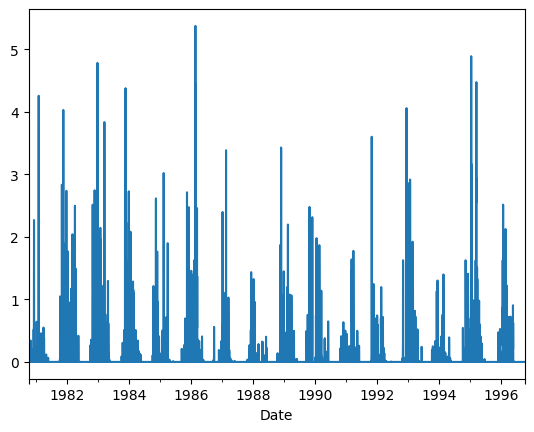

In [9]:
s.loc[:,'basin_snow_1'].plot()

In [9]:
import datetime
with open(statvarfile, "r") as fid:
    nvals = int(fid.readline().strip())
    var_names = []
    for header in range(nvals):
        nm, elem = fid.readline().strip().split()
        nm = nm + "_" + elem
        var_names.append(nm)

    columns = ["ID"] + ["Year", "Month", "Day", "Hour", "Minute", "Second"] + var_names
    stat_df = pd.read_csv(fid, sep="\\s+", names=columns)
    dts = []
    for index, irow in stat_df.iterrows():
        dt = datetime.datetime(
            year=int(irow["Year"]),
            month=int(irow["Month"]),
            day=int(irow["Day"]),
            hour=int(irow["Hour"]),
            minute=int(irow["Minute"]),
            second=int(irow["Second"]),
        )
        dts.append(dt)

    stat_df["Date"] = dts
    stat_df = stat_df.loc[:,["Date"]+[c for c in stat_df.columns if c not in ["Date", "Year", "Month","Day", "Hour", "Minute", "Second"]]]
    stat_df = stat_df.set_index('Date')

In [10]:
stat_df

,ID,basin_tmin_1,basin_tmax_1,basin_temp_1,basin_ppt_1,basin_rain_1,basin_snow_1,basin_potsw_1,basin_potet_1,basin_net_ppt_1,...,basin_perv_et_1,basin_pk_precip_1,basin_snowevap_1,basin_soil_rechr_1,basin_soil_to_gw_1,basin_ssin_1,basin_sz2gw_1,basin_storage_1,orad_1,runoff_1
Date,,,,,,,,,,,,,,,,,,,,,
1980-10-01,1,33.340302,81.759139,57.549721,0.0,0.0,0.0,445.026031,0.338339,0.0,...,0.008907,0.0,0.0,0.000000,0.0,0.0,0.0,3.087321,445.213104,2.3
1980-10-02,2,35.340302,77.759139,56.549721,0.0,0.0,0.0,429.844508,0.318990,0.0,...,0.007627,0.0,0.0,0.000000,0.0,0.0,0.0,3.075917,429.953369,2.3
1980-10-03,3,33.340302,79.759140,56.549721,0.0,0.0,0.0,431.914399,0.320536,0.0,...,0.007001,0.0,0.0,0.000000,0.0,0.0,0.0,3.065135,432.113892,2.3
1980-10-04,4,35.340302,76.759139,56.049721,0.0,0.0,0.0,418.783734,0.307000,0.0,...,0.006124,0.0,0.0,0.000000,0.0,0.0,0.0,3.055226,418.927826,2.3
1980-10-05,5,35.340302,76.759139,56.049721,0.0,0.0,0.0,414.883982,0.304156,0.0,...,0.005563,0.0,0.0,0.000000,0.0,0.0,0.0,3.045874,415.059479,2.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1996-09-26,5840,32.399340,65.061721,48.730531,0.0,0.0,0.0,380.186923,0.139345,0.0,...,0.040048,0.0,0.0,0.527803,0.0,0.0,0.0,9.486146,379.136108,2.8
1996-09-27,5841,32.399340,64.061722,48.230531,0.0,0.0,0.0,364.947583,0.131742,0.0,...,0.035452,0.0,0.0,0.492537,0.0,0.0,0.0,9.433246,363.703400,2.8
1996-09-28,5842,33.399340,71.061721,52.230531,0.0,0.0,0.0,422.201325,0.171133,0.0,...,0.042547,0.0,0.0,0.450124,0.0,0.0,0.0,9.373305,421.866425,2.8


In [97]:
outfl = c.model_wd / c.control_obj.get_values('model_output_file')[0]

In [106]:
with open(outfl, "r") as fl:
    lines = fl.read()

In [108]:
lines

'\n\n                         U.S. Geological Survey\n               Precipitation-Runoff Modeling System (PRMS)\n                        Version 6.0.0 02/01/2025\n\n--------------------------------------------------------------------\n        Process            Available Modules\n--------------------------------------------------------------------\n  Basin Definition: basin\n    Cascading Flow: cascade\n  Time Series Data: obs, water_use_read, dynamic_param_read\n                    dynamic_soil_param_read\n   Potet Solar Rad: soltab\n  Temperature Dist: temp_1sta, temp_laps, temp_dist2, climate_hru,\n                    temp_map\n       Precip Dist: precip_1sta, precip_laps, precip_dist2,\n                    climate_hru, precip_map\nTemp & Precip Dist: xyz_dist, ide_dist\n    Solar Rad Dist: ccsolrad, ddsolrad, climate_hru\nTranspiration Dist: transp_tindex, climate_hru, transp_frost\n      Potential ET: potet_hamon, potet_jh, potet_pan, climate_hru,\n                    potet_hs, p

In [84]:
d = pd.read_csv(c._out_pth / 'prms_summary.csv')
multi_col = d.loc[0].to_dict()
dsel = d.loc[1:]
dtindx = pd.DatetimeIndex(dsel['Date'])
dsel = dsel.drop(columns='Date')
#dsel.apply(pd.to_numeric)
dsel.index=dtindx
dsel.columns = pd.MultiIndex.from_tuples([(col, unit) for col, unit in multi_col.items() if col != "Date"])
dsel = dsel.apply(pd.to_numeric)
#newd = newd.drop(columns='Date')

In [73]:
dsel.columns

Index([        ('basin_potet', 'inches/day'),
               ('basin_actet', 'inches/day'),
          ('basin_dprst_evap', 'inches/day'),
         ('basin_imperv_evap', 'inches/day'),
          ('basin_intcp_evap', 'inches/day'),
            ('basin_lakeevap', 'inches/day'),
             ('basin_perv_et', 'inches/day'),
            ('basin_snowevap', 'inches/day'),
                 ('basin_swrad', 'Langleys'),
                 ('basin_ppt', 'inches/day'),
           ('basin_pk_precip', 'inches/day'),
                   ('basin_tmax', 'degrees'),
                   ('basin_tmin', 'degrees'),
               ('basin_snowcov', 'fraction'),
           ('basin_total_storage', 'inches'),
         ('basin_surface_storage', 'inches'),
             ('basin_dprst_volcl', 'inches'),
             ('basin_dprst_volop', 'inches'),
                  ('basin_gwstor', 'inches'),
             ('basin_imperv_stor', 'inches'),
              ('basin_intcp_stor', 'inches'),
               ('basin_lake_stor',

<Axes: xlabel='Date'>

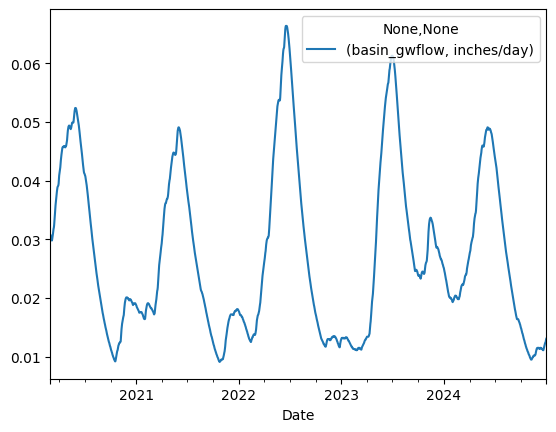

In [96]:
dsel.loc[slice('2020-03-01', None),dsel.columns.get_level_values(0)=='basin_gwflow'].plot()

In [85]:
dsel.loc[:,cidx['basin_swrad',:]]

,basin_swrad
,Langleys
Date,
2020-01-01,53.8764
2020-01-02,54.4078
2020-01-03,54.4127
2020-01-04,54.9151
2020-01-05,55.0459
...,...
2024-12-27,53.0614
2024-12-28,53.2139


In [38]:
dtindx

0       year-month-day
1           2020-01-01
2           2020-01-02
3           2020-01-03
4           2020-01-04
             ...      
1823        2024-12-27
1824        2024-12-28
1825        2024-12-29
1826        2024-12-30
1827        2024-12-31
Name: Date, Length: 1828, dtype: object

In [6]:
pth = Path('C:/Users/CNB968/OneDrive - MT/GitHub/insolpy/Examples/100901010102.nc')

In [3]:
import rasterio as rio
pth = Path(r'D:\ArcGIS_Projects\Yellowstone\Upper Yellowstone\prms\MT_hydro_SRTM_30m_clipped.tif')

with rio.open(pth) as src:
    data = src.read(1)
    transform = src.transform
    resolution = src.res

affine.Affine